# Customer Marketing Analysis with Python

## 1. Business Objective

The goal of this project is to analyze customer demographics, purchasing behavior, spending patterns, and marketing campaign performance using Python.

The analysis aims to identify key characteristics of the customer base and highlight patterns that can support marketing and customer engagement decisions.
### Key Questions

- Who are the company's customers?
- How is customer spending distributed?
- Which purchasing channels are used most frequently?
- How have previous marketing campaigns performed?

## 2. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\customer-marketing-analysis\Data\marketing_campaign.csv", sep ="\t")

In [99]:
df.shape

(2240, 34)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## 3. Data Understanding

The dataset contains customer demographic information, spending behavior, purchasing channels, and responses to previous marketing campaigns.

In [14]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [15]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [16]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [100]:
df.isna().sum()

ID                      0
Year_Birth              3
Education               0
Marital_Status          0
Income                 25
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
Age                     3
Total_Spending          0
Total_Purchase          0
Total_Purchases         0
Total_Children          0
Age_Group               5
Spending_Segment        0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["ID"].duplicated().sum()

np.int64(0)

## 4. Data Cleaning

The initial data-quality assessment identified several issues:

- Missing values in `Income`
- Invalid birth years
- An extreme income value
- Unusual categories in `Marital_Status`
- `Dt_Customer` stored as text

These issues are cleaned before performing the analysis.

In [ ]:
# Replace unrealistic birth years with missing values
df.loc[df["Year_Birth"]< 1940, "Year_Birth"] = np.nan

In [ ]:
# Treat the extreme income value as missing
df.loc[df["Income"]> 200000), "Income"] = np.nan

In [ ]:
df["Marital_Status"] = df["Marital_Status"].replace(
    ["Alone", "Absurd", "YOLO"],
    "Other"
)

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")

In [27]:
df= df.drop(columns = ["Z_CostContact", "Z_Revenue"])

In [ ]:
df.info()

In [ ]:
df.isna().sum()

## 5. Feature Engineering

Several features are created to make the customer analysis easier to interpret.

- `Age` — estimated customer age
- `Total_Spending` — total spending across all product categories
- `Total_Purchases` — total purchases across web, catalog, and store channels
- `Total_Children` — number of children and teenagers in the household

In [52]:
df["Age"] = 2014 - df["Year_Birth"]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,5524,1957.0,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,0,0,0,0,0,1,57.0
1,2174,1954.0,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,0,0,0,0,0,60.0
2,4141,1965.0,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,0,0,0,0,0,49.0
3,6182,1984.0,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,0,0,0,0,0,30.0
4,5324,1981.0,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,0,0,0,0,0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967.0,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,4,5,0,0,0,0,0,0,0,47.0
2236,4001,1946.0,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,5,7,0,0,0,1,0,0,0,68.0
2237,7270,1981.0,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,13,6,0,1,0,0,0,0,0,33.0
2238,8235,1956.0,Master,Together,69245.0,0,1,2014-01-24,8,428,...,10,3,0,0,0,0,0,0,0,58.0


In [53]:
df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957.0,57.0
1,1954.0,60.0
2,1965.0,49.0
3,1984.0,30.0
4,1981.0,33.0


In [54]:
df["Age"].describe()

count    2237.000000
mean       45.098346
std        11.701917
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64

In [55]:
df["Total_Spending"] = df[['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']].sum(axis=1)

In [56]:
df["Total_Spending"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spending, dtype: float64

In [57]:
df[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "Total_Spending"
]].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


In [61]:
# NumDealsPurchases is not included because it represents purchases made using deals rather than an additional purchasing channel
df["Total_Purchases"] = df[[ 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

In [62]:
df["Total_Purchases"].describe()

count    2240.000000
mean       12.537054
std         7.205741
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        32.000000
Name: Total_Purchases, dtype: float64

In [63]:
df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "Total_Purchases"
]].head()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases
0,8,10,4,22
1,1,1,2,4
2,8,2,10,20
3,2,0,4,6
4,5,3,6,14


In [64]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [65]:
df[["Kidhome", "Teenhome", "Total_Children"]].head()

,Kidhome,Teenhome,Total_Children
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


In [66]:
df["Total_Children"].describe()

count    2240.000000
mean        0.950446
std         0.751803
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Total_Children, dtype: float64

In [69]:
df[[
    "Age",
    "Total_Spending",
    "Total_Purchases",
    "Total_Children"
]].dtypes

Age                float64
Total_Spending       int64
Total_Purchases      int64
Total_Children       int64
dtype: object

## 6. Exploratory Data Analysis

This section explores the customer base, spending behavior, purchasing channels, and marketing campaign performance.

### 6.1 Customer Age Distribution

Understanding the age distribution helps identify the primary demographic groups within the customer base.

In [73]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 40, 50, 60, 70, 100],
    labels=['18–29','30–39','40–49','50–59','60–69','70+']
)

In [102]:
age_counts = df["Age_Group"].value_counts().sort_index()
age_counts

Age_Group
18–29    257
30–39    588
40–49    649
50–59    475
60–69    257
70+        9
Name: count, dtype: int64

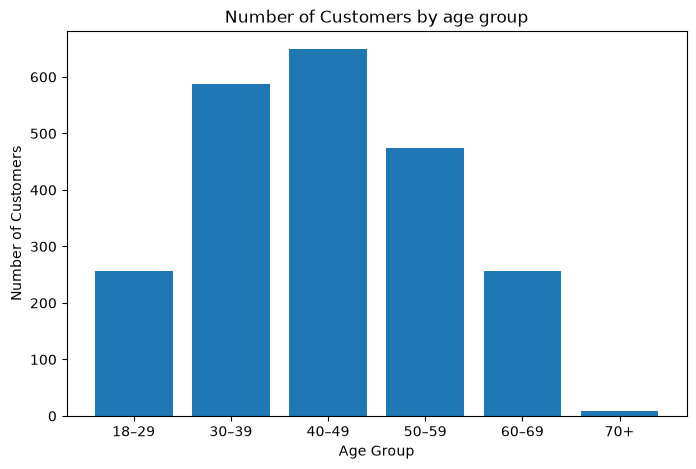

In [78]:
plt.figure(figsize=(8, 5))
plt.bar(age_counts.index, age_counts.values)
plt.title('Number of Customers by age group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

**Finding:** Customers aged 30–49 represent approximately 55% of the customer base, making this the core age group in the dataset.

### 6.2 Education Distribution

Education level provides additional context about the demographic profile of the customer base.

In [ ]:
education_counts = df["Education"].value_counts()

education_pct = (
    df["Education"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

education_pct

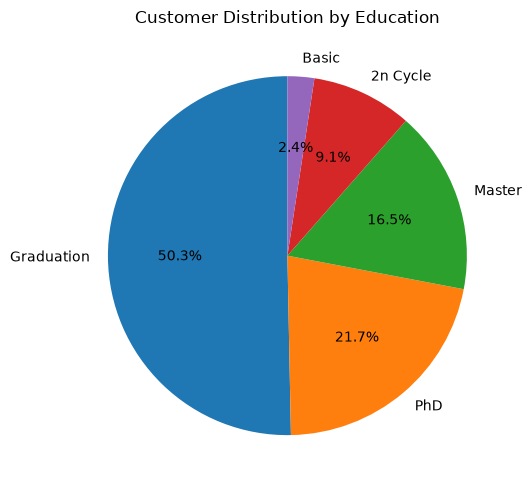

In [98]:
education_counts = df["Education"].value_counts()
plt.figure(figsize=(8, 5))

plt.pie(
    education_counts.values,
    labels=education_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Education")

plt.tight_layout()
plt.show()

**Finding:** Graduation is the most common education level, accounting for approximately half of the customer base, followed by PhD and Master.

### 6.3 Marital Status Distribution

Marital status provides an overview of the household and relationship profile of the customer base.

In [80]:
marital_counts = df["Marital_Status"].value_counts()


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Other         7
Name: count, dtype: int64

In [81]:
marital_pct = df["Marital_Status"].value_counts(normalize=True) * 100
marital_pct.round(1)

Marital_Status
Married     38.6
Together    25.9
Single      21.4
Divorced    10.4
Widow        3.4
Other        0.3
Name: proportion, dtype: float64

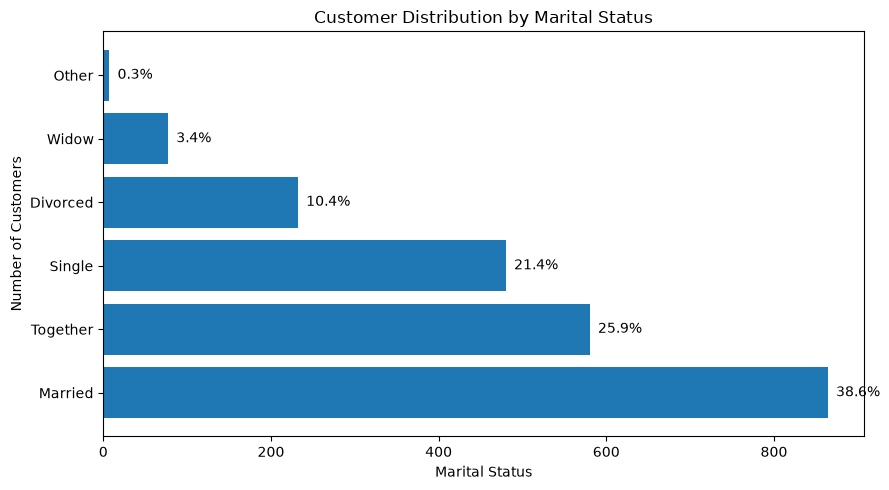

In [108]:
plt.figure(figsize=(9, 5))

bars = plt.barh(marital_counts.index, marital_counts.values)

plt.title("Customer Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")

for bar, pct in zip(bars, marital_pct):
    plt.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center"
    )
    plt.tight_layout()
plt.show()

**Finding:** Married customers represent the largest group at 38.6%, followed by Together at 25.9%. Combined, these groups account for 64.5% of the customer base.

### 6.4 Customer Spending

Customer spending is analyzed to understand how spending is distributed across the customer base.

In [85]:
df["Spending_Segment"] = pd.qcut(
    df["Total_Spending"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [86]:
df["Spending_Segment"].value_counts().sort_index()

Spending_Segment
Low          560
Medium       561
High         559
Very High    560
Name: count, dtype: int64

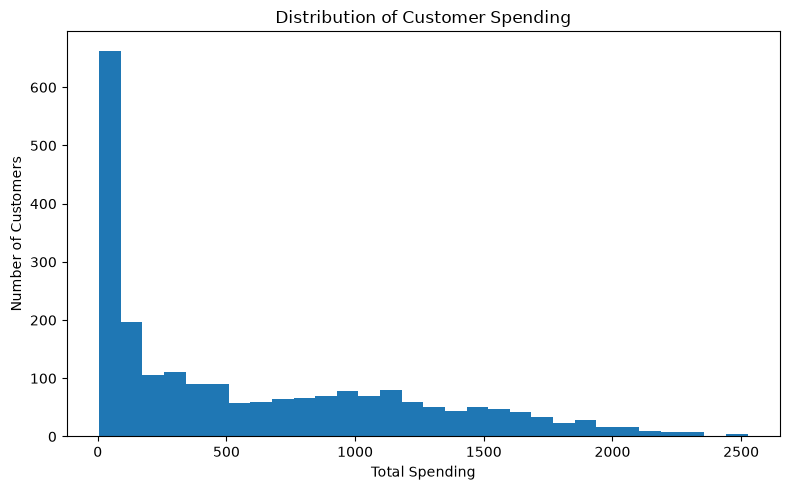

In [88]:
plt.figure(figsize=(8, 5))

plt.hist(df["Total_Spending"], bins=30)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**Finding:** Customer spending is strongly right-skewed, with most customers concentrated at lower spending levels and a smaller group of customers spending substantially more.

### 6.5 Purchasing Channels

Understanding purchasing channels helps identify how customers interact with the business.

In [89]:
channel_purchases = pd.Series({
    "Web": df["NumWebPurchases"].sum(),
    "Catalog": df["NumCatalogPurchases"].sum(),
    "Store": df["NumStorePurchases"].sum()
})

channel_purchases

Web         9150
Catalog     5963
Store      12970
dtype: int64

In [90]:
channel_pct = (
    channel_purchases / channel_purchases.sum() * 100
)

channel_pct.round(1)

Web        32.6
Catalog    21.2
Store      46.2
dtype: float64

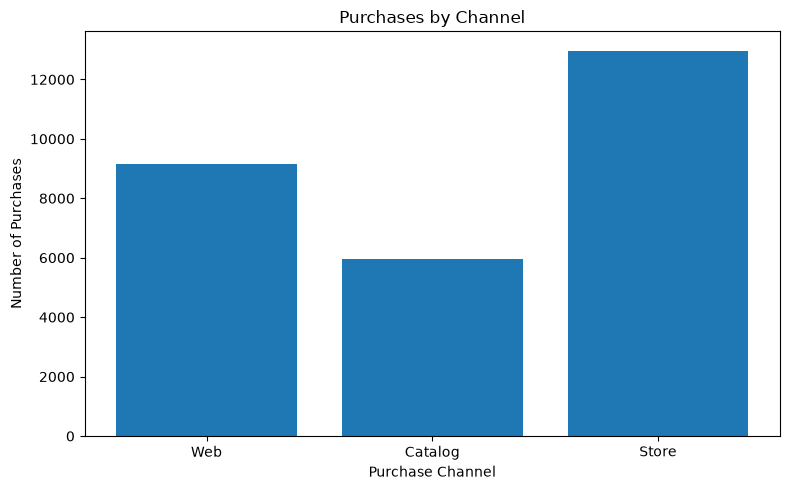

In [91]:
plt.figure(figsize=(8, 5))

plt.bar(channel_purchases.index, channel_purchases.values)

plt.title("Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")

plt.tight_layout()
plt.show()

**Finding:** Store purchases are the most common channel, representing 46.2% of all recorded purchases, followed by web purchases at 32.6% and catalog purchases at 21.2%.

### 6.6 Marketing Campaign Performance

The dataset contains customer acceptance indicators for five previous campaigns and a response indicator for the latest campaign.

The analysis compares campaign acceptance rates and the overall response rate.

In [92]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

campaign_rates = df[campaign_cols].mean() * 100
campaign_rates.round(1)

AcceptedCmp1    6.4
AcceptedCmp2    1.3
AcceptedCmp3    7.3
AcceptedCmp4    7.5
AcceptedCmp5    7.3
dtype: float64

In [94]:
response_rate = df["Response"].mean() * 100
response_rate.round(1)

np.float64(14.9)

**Latest Campaign Response:** 14.9% of customers responded to the latest campaign.

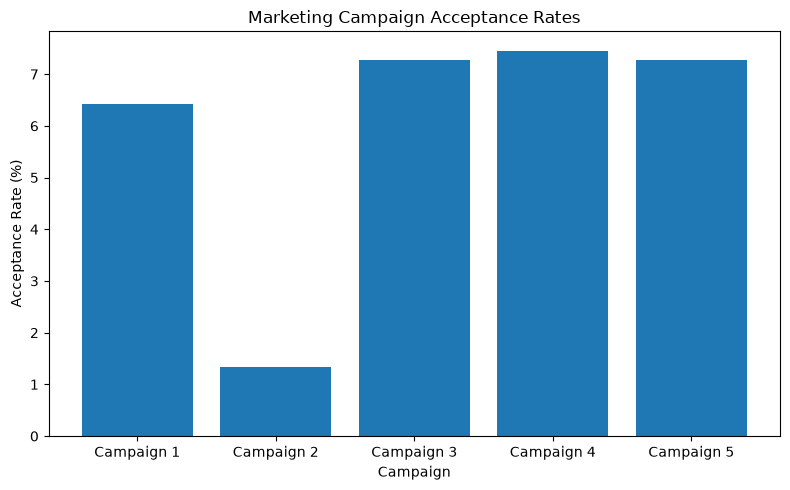

In [95]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Campaign 1", "Campaign 2", "Campaign 3", "Campaign 4", "Campaign 5"],
    campaign_rates.values
)

plt.title("Marketing Campaign Acceptance Rates")
plt.xlabel("Campaign")
plt.ylabel("Acceptance Rate (%)")

plt.tight_layout()
plt.show()

**Finding:** Campaign 4 achieved the highest acceptance rate at 7.5%, while Campaign 2 had the lowest at 1.3%. The relatively large difference suggests that campaign performance varied considerably across campaigns.

## 7. Business Insights

### 1. Core Customer Demographic
Customers aged 30–49 represent approximately 55% of the customer base, making this the core age group in the dataset.

### 2. Education Profile
Graduation is the most common education level among customers, followed by PhD and Master.

### 3. Household Profile
Married and Together customers account for 64.5% of the customer base, making partnered customers the dominant household group.

### 4. Purchasing Channels
Store purchases represent 46.2% of all recorded purchases, followed by web purchases at 32.6% and catalog purchases at 21.2%.

### 5. Marketing Campaign Performance
Campaign 4 achieved the highest acceptance rate among previous campaigns at 7.5%, while Campaign 2 had the lowest at 1.3%. The latest campaign received a 14.9% response rate.

### 6. Spending Distribution
Customer spending is strongly right-skewed, with most customers spending relatively modest amounts and a smaller group accounting for substantially higher spending levels.

## 8. Conclusion

This analysis used Python to explore customer demographics, purchasing behavior, spending patterns, and marketing campaign performance.

The analysis identified a customer base primarily concentrated in the 30–49 age range, with partnered customers representing the majority of the dataset. Store purchases were the most common purchasing channel, while campaign performance varied considerably across previous campaigns.

The project demonstrates how Python and pandas can be used to clean real-world data, engineer useful features, perform exploratory analysis, and translate data into clear business insights.

## 9. Python Skills Demonstrated

### Python & pandas
- Data loading and inspection
- DataFrame manipulation
- Filtering and conditional transformations
- Missing-value handling
- Duplicate detection
- Categorical data cleaning
- Datetime conversion
- Aggregation with `value_counts()` and `groupby()`
- Feature engineering
- Quantile-based segmentation
- Descriptive statistics

### Data Visualization
- Bar charts
- Horizontal bar charts
- Histograms
- Pie charts
- Chart labeling and formatting

### Analytical Skills
- Data-quality assessment
- Exploratory data analysis
- Identifying distributions and patterns
- Calculating percentages and rates
- Translating analytical results into business insights